# Catalog properties and Mc estimation

Interactive inspection tool for earthquake catalogs:

- **Mc estimation** from:
  - `eq_mag_prediction` (`MAXC`, `MBS`)
  - `etas` (`KS` test via `etas.mc_b_est`)
  - `seismostats` (`MAXC`, `MBS`, `KS`)
  - `csep` (`MAXC` via `CSEPCatalog.magnitude_counts` and `CSEP_MW_BINS`)
- **Spatial map** (event locations, sized by magnitude)
- **Magnitude vs time**
- **Magnitude histogram**
- **Inter-event time distributions** (all events and events above Mc)

By default this notebook loads the ingested **Central Italy Amatrice** catalog
(`central_italy_amatrice.csv`, Tan et al. 2021; produced by
`eq_mag_prediction.ingestion.ingest_central_italy_amatrice`), filtered with
`catalog_filters.earthquake_criterion` to events from **2016 onward**
(the 2016–2017 Central Italy sequence).

Raw data: [Zenodo 4736089](https://zenodo.org/records/4736089).

Set `CATALOG_PATH` / `CATALOG_START_YEAR` below to inspect another catalog or time window.

In [1]:
%matplotlib inline

from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / "etas").is_dir() and (REPO_ROOT.parent / "etas").is_dir():
    REPO_ROOT = REPO_ROOT.parent

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import etas.catalog_inspection as catalog_inspection
import eq_mag_prediction.data.catalog_methods  # noqa: F401 — registers .catalog_tools accessor
from eq_mag_prediction.utilities import catalog_filters, time_conversions

# --- locate eq_mag_prediction checkout (for ingested catalogs) ---
_DEFAULT_CATALOG_REL = "results/catalogs/ingested/central_italy_amatrice.csv"
EQ_MAG_ROOT = None
for _candidate in (
    REPO_ROOT.parent / "eq_mag_prediction/eq_mag_prediction",
    REPO_ROOT.parent / "eq_mag_prediction/eq_mag_prediction_clean",
    REPO_ROOT.parent / "eq_mag_prediction",
):
    if (_candidate / "eq_mag_prediction").is_dir() and str(_candidate) not in sys.path:
        sys.path.insert(0, str(_candidate))
    if (_candidate / _DEFAULT_CATALOG_REL).is_file():
        EQ_MAG_ROOT = _candidate
        break

if EQ_MAG_ROOT is None:
    raise FileNotFoundError(
        "Could not find ingested Central Italy catalog. Run "
        "`python -m eq_mag_prediction.ingestion.ingest_central_italy_amatrice` "
        "in eq_mag_prediction_clean."
    )


def load_magnet_ingested_catalog(
    path: Path,
    *,
    start_timestamp: int | None = None,
    min_magnitude: float = 0.0,
) -> pd.DataFrame:
    """Load a MAGNET ingested CSV and optionally filter with earthquake_criterion."""
    df = pd.read_csv(path)
    if start_timestamp is not None:
        filter_df = df.copy()
        filter_df["depth"] = filter_df["depth"].fillna(999)
        mask = catalog_filters.earthquake_criterion(
            filter_df,
            longitude_range=(
                filter_df.longitude.min(),
                filter_df.longitude.max(),
            ),
            latitude_range=(
                filter_df.latitude.min(),
                filter_df.latitude.max(),
            ),
            start_timestamp=start_timestamp,
            max_depth=999,
            min_magnitude=min_magnitude,
        )
        df = df.loc[mask].reset_index(drop=True)
    if pd.api.types.is_numeric_dtype(df["time"]):
        df["time"] = (
            pd.to_datetime(df["time"], unit="s", utc=True)
            .dt.tz_convert(None)
        )
    return catalog_inspection.normalize_catalog_columns(df)


# --- user parameters ---
CATALOG_LABEL = "Central Italy Amatrice (Tan et al. 2021)"
CATALOG_PATH = EQ_MAG_ROOT / _DEFAULT_CATALOG_REL
CATALOG_START_YEAR = 2016
CATALOG_MIN_MAGNITUDE = -3.0  # keep sub-zero M_L from the Tan et al. catalog
CATALOG_START_TIMESTAMP = time_conversions.datetime_utc_to_time(
    CATALOG_START_YEAR, 1, 1
)
DELTA_M = None  # infer from catalog when None
ETAS_P_PASS = 0.05
ETAS_N_SAMPLES = 500
MC_MAX_EVENTS = 50_000  # KS bootstrap subsample; None = full catalog
INTEREVENT_MC_FOR_FILTER = "eq_mag MAXC"  # key from mc_lines, e.g. "seismostats KS"

print(f"REPO_ROOT = {REPO_ROOT}")
print(f"EQ_MAG_ROOT = {EQ_MAG_ROOT}")
print(f"CATALOG_PATH = {CATALOG_PATH}")
print(f"CATALOG_START_YEAR = {CATALOG_START_YEAR}")
print(f"CATALOG_MIN_MAGNITUDE = {CATALOG_MIN_MAGNITUDE}")
print(f"MC_MAX_EVENTS = {MC_MAX_EVENTS}")


REPO_ROOT = /home/neriberman/Repos/etas
EQ_MAG_ROOT = /home/neriberman/Repos/eq_mag_prediction/eq_mag_prediction
CATALOG_PATH = /home/neriberman/Repos/eq_mag_prediction/eq_mag_prediction/results/catalogs/ingested/central_italy_amatrice.csv
CATALOG_START_YEAR = 2016
CATALOG_MIN_MAGNITUDE = -3.0
MC_MAX_EVENTS = 50000


## Load catalog


In [2]:
catalog = load_magnet_ingested_catalog(
    CATALOG_PATH,
    start_timestamp=CATALOG_START_TIMESTAMP,
    min_magnitude=CATALOG_MIN_MAGNITUDE,
)
print(f"Loaded {len(catalog):,} events")


Loaded 873,490 events


## Catalog summary


In [3]:
summary = catalog_inspection.catalog_summary(catalog)

summary_df = pd.DataFrame([summary]).T
summary_df.columns = ["value"]
display(Markdown("### Catalog summary"))
display(summary_df)


### Catalog summary

,value
n_events,873490
time_start,2016-08-15 00:06:25.808000088
time_end,2017-08-15 23:59:35.128999949
duration_days,365.995247
magnitude_min,-2.55387
magnitude_max,6.03399
magnitude_mean,0.174462
latitude_range,"(42.16465, 43.92816)"
longitude_range,"(11.68818, 13.82013)"


## Mc estimation

KS-based estimators bootstrap over the catalog (or an `MC_MAX_EVENTS` subsample when set).
The Amatrice catalog has ~870k events; by default Mc uses a 50k subsample so this step
finishes in a few minutes with `ETAS_N_SAMPLES=500`.


In [ ]:
import time

mc_catalog = catalog
if MC_MAX_EVENTS is not None and len(catalog) > MC_MAX_EVENTS:
    mc_catalog = (
        catalog.sample(n=MC_MAX_EVENTS, random_state=0)
        .sort_values("time")
        .reset_index(drop=True)
    )
    print(
        f"Mc estimation uses {len(mc_catalog):,}-event subsample "
        f"(MC_MAX_EVENTS={MC_MAX_EVENTS:,})"
    )

print(
    f"Computing Mc estimates on {len(mc_catalog):,} events "
    f"(ETAS_N_SAMPLES={ETAS_N_SAMPLES}; this can take several minutes)..."
)
t0 = time.perf_counter()
estimates = catalog_inspection.compute_all_mc(
    mc_catalog,
    delta_m=DELTA_M,
    p_pass=ETAS_P_PASS,
    n_samples=ETAS_N_SAMPLES,
    include_seismostats=False,
)
mc_lines = catalog_inspection.mc_lines_from_estimates(estimates)
print(f"Done in {time.perf_counter() - t0:.1f}s")


Mc estimation uses 50,000-event subsample (MC_MAX_EVENTS=50,000)
Computing Mc estimates on 50,000 events (ETAS_N_SAMPLES=500; this can take several minutes)...


## Mc results


In [ ]:
summary_df = pd.DataFrame([summary | estimates.as_dict()]).T
summary_df.columns = ["value"]
display(Markdown("### Catalog summary + Mc metadata"))
display(summary_df)

display(Markdown("### Mc estimates"))
for label, value in mc_lines.items():
    extra = ""
    if label == "etas KS" and estimates.etas_ks_p_value is not None:
        extra = f" (p={estimates.etas_ks_p_value:.3f})"
    if label == "seismostats KS" and estimates.seismostats_ks_p_value is not None:
        extra = f" (p={estimates.seismostats_ks_p_value:.3f})"
    display(Markdown(f"- **{label}**: `{value:.2f}`{extra}"))
display(Markdown(f"- **delta_m used for binned methods**: `{estimates.delta_m:.3f}`"))
display(
    Markdown(
        "_Note: PyCSEP does not ship KS/MBS Mc estimators; "
        "`csep MAXC` uses `CSEPCatalog.magnitude_counts` with `CSEP_MW_BINS`._"
    )
)


### Catalog summary + Mc metadata

,value
n_events,55280
time_start,1985-01-01 07:08:34
time_end,2012-04-24 19:44:09
duration_days,9975.524711
magnitude_min,2.5
magnitude_max,7.28
magnitude_mean,2.918078
latitude_range,"(31.537, 42.9122)"
longitude_range,"(-125.4, -113.8)"
eq_mag_maxc,2.8


### Mc estimates

- **MAXC**: `2.80`

- **MBS**: `2.60`

- **etas KS**: `3.54` (p=0.052)

- **delta_m used for binned methods**: `0.010`

_Note: PyCSEP does not ship KS/MBS Mc estimators; `csep MAXC` uses `CSEPCatalog.magnitude_counts` with `CSEP_MW_BINS`._

Setting extent: [-126.4    -112.8      30.537    43.9122]


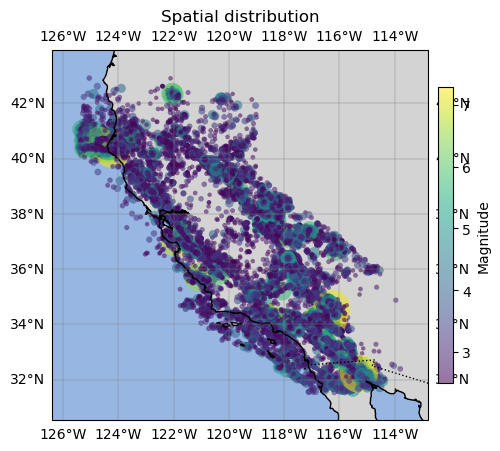

In [ ]:
ax = catalog.catalog_tools.plot_map(
    c=catalog["magnitude"],
    cmap="viridis",
    alpha=0.55,
    edgecolors="none",
)
cb = plt.colorbar(ax.collections[-1], ax=ax, shrink=0.8, pad=0.02)
cb.set_label("Magnitude")
ax.set_title(f"{CATALOG_LABEL} — spatial distribution")
plt.show()


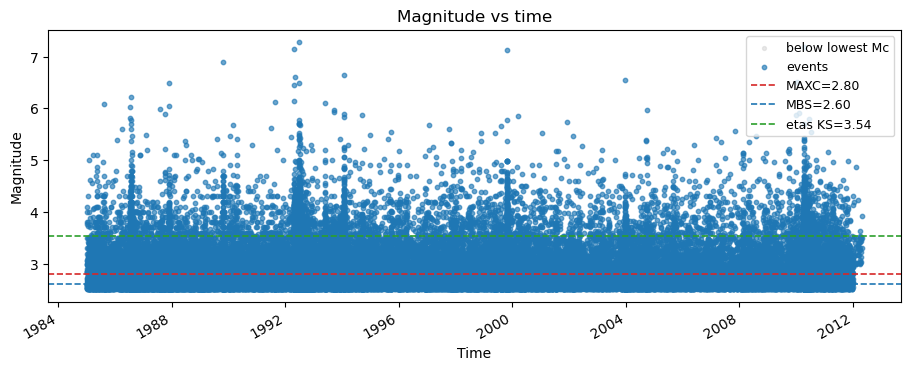

In [ ]:
fig, ax = catalog.catalog_tools.plot_magnitude_vs_time(mc_lines=mc_lines)
plt.show()


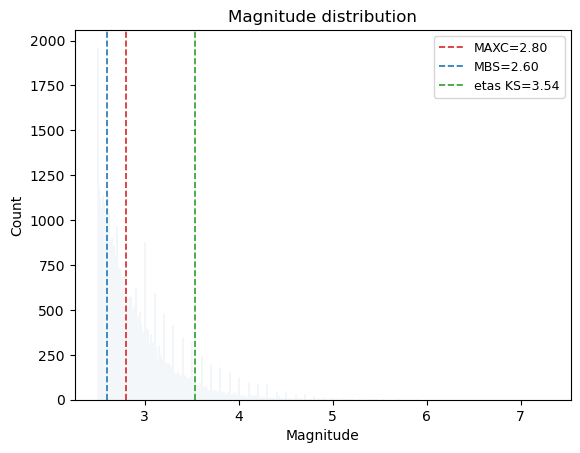

In [ ]:
fig, ax = catalog.catalog_tools.plot_magnitude_histogram(
    mc_lines=mc_lines,
    bin_width=estimates.delta_m,
)
plt.show()


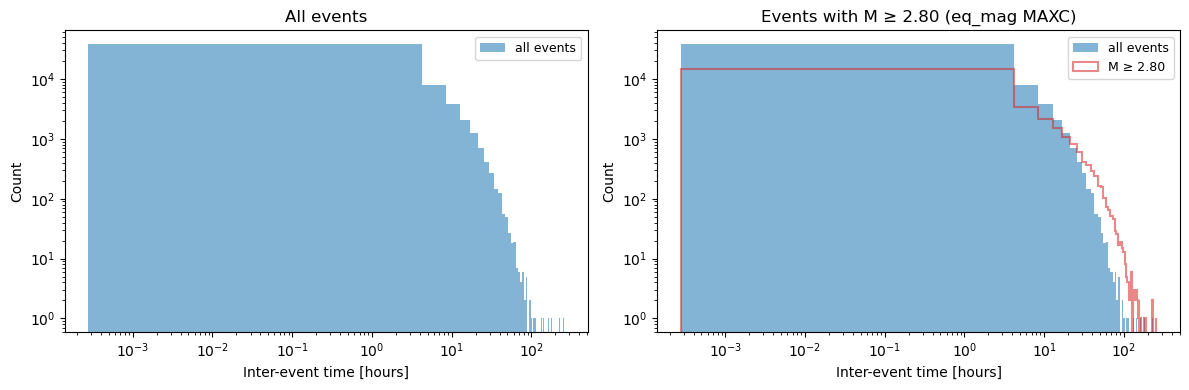

In [ ]:
mc_for_filter = mc_lines.get(INTEREVENT_MC_FOR_FILTER)
if mc_for_filter is None:
    mc_for_filter = next(iter(mc_lines.values()))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

catalog.catalog_tools.plot_interevent_time_distribution(ax=axes[0], unit="hours", log_scale=True)
axes[0].set_title("All events")

catalog.catalog_tools.plot_interevent_time_distribution(
    ax=axes[1],
    mc=mc_for_filter,
    unit="hours",
    log_scale=True,
)
axes[1].set_title(f"Events with M ≥ {mc_for_filter:.2f} ({INTEREVENT_MC_FOR_FILTER})")

plt.tight_layout()
plt.show()
